# 05 — A/B simulado + inferência causal

Duas perguntas diferentes:

1. **A/B simulado** — *se* randomizássemos uma expansão de insumos UHC entre países, conseguiríamos
   detectar o efeito? (poder, CUPED, correção múltipla)
2. **Causal observacional** — países que cruzaram o limiar do proxy UHC tiveram ganho de LE?
   (DiD escalonado, event study, controle sintético)

In [1]:
import sys, json, warnings
from pathlib import Path
ROOT = Path.cwd() if (Path.cwd() / "src").exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT))
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from config import settings
from src.utils.io import load_parquet
from src.analysis import eda
from src.viz import style

style.use_matplotlib()
pd.set_option("display.max_columns", 40, "display.width", 160, "display.precision", 2)
abt = load_parquet("gold", "abt_country_year")
print(f"ABT: {abt.shape[0]:,} linhas x {abt.shape[1]} colunas | "
      f"{abt.country_id.nunique()} paises | {abt.year.min()}-{abt.year.max()}")

ABT: 7,378 linhas x 37 colunas | 217 paises | 1990-2023


## 1. A/B simulado (unidade = país, snapshot 2019, uplift de 20% nos insumos)

In [2]:
from src.abtesting.simulate_ab import simulate
ab = simulate(uplift=0.2, seed=42, abt=abt)
rows = []
for k, r in ab["outcomes"].items():
    rows.append({"outcome": k, "efeito_real_modelo": r["true_effect_model"], "diff": r["diff"], "p": r["p"],
                 "diff_cuped": r["cuped"]["diff"], "p_cuped": r["cuped"]["p"],
                 "reducao_var_cuped": r["cuped"]["variance_reduction"], "p_holm": r["p_holm"],
                 "MDE": r["power"]["mde_abs"], "MDE_cuped": r["power"]["mde_abs_cuped"],
                 "n_por_braco_80pct": r["power"]["n_per_arm_for_80pct_power"]})
pd.DataFrame(rows).round(3)

,outcome,efeito_real_modelo,diff,p,diff_cuped,p_cuped,reducao_var_cuped,p_holm,MDE,MDE_cuped,n_por_braco_80pct
0,life_expectancy,1.18,7.34e-01,0.55,0.34,0.54,0.79,0.87,3.41,1.58,790
1,child_mortality,-5.21,-7.05e+00,0.17,-4.52,0.24,0.44,0.71,14.40,10.81,726
2,milestone_prob,0.06,-3.00e-03,0.96,0.02,0.44,0.73,0.87,0.15,0.08,632


In [3]:
# poder empirico: repete a randomizacao com varias seeds (efeito fixo, ruido novo)
from src.abtesting.simulate_ab import simulate
sig = {"raw": 0, "cuped": 0}; n_sims = 40
for s in range(n_sims):
    r = simulate(uplift=0.2, seed=1000 + s, abt=abt)["outcomes"]["life_expectancy"]
    sig["raw"] += r["p"] < 0.05; sig["cuped"] += r["cuped"]["p"] < 0.05
print({k: f"{v / n_sims:.0%}" for k, v in sig.items()}, "de poder empirico (LE, alpha=5%)")

{'raw': '15%', 'cuped': '60%'} de poder empirico (LE, alpha=5%)


**Leitura:** com ~190 países (≈96 por braço) o experimento é **subdimensionado**: o MDE para LE
é de ~3.4 anos sem CUPED e ~1.6 com CUPED, enquanto o efeito "verdadeiro" (segundo o M1) de
+20% nos insumos é ~1.2 ano. CUPED (covariável = LE observada em 2015) reduz ~80% da variância
e quadruplica o poder empírico (~15% → ~60% nas simulações) — mas nem assim chega a 80%;
seriam necessários ~790 países por braço sem CUPED. Randomizar no nível país é
estatisticamente caro: precisaria de mais unidades (subnacionais) ou horizonte maior.

## 2. DiD: da estimativa ingênua à robusta

In [4]:
from src.abtesting.causal_did import run
cd = run(abt, n_boot=199)
tab = pd.DataFrame([
    {"estimador": "TWFE (FE país+ano)", **{k: cd["twfe"][k] for k in ("att", "p")}, "ic95": cd["twfe"]["ci95"]},
    {"estimador": "TWFE + log PIB", **{k: cd["twfe_controls"][k] for k in ("att", "p")}, "ic95": cd["twfe_controls"]["ci95"]},
    {"estimador": "Escalonado (nunca-tratados)", **{k: cd["staggered"][k] for k in ("att", "p")}, "ic95": cd["staggered"]["ci95"]},
    {"estimador": "Escalonado (ainda-não-tratados)", **{k: cd["staggered_notyet"][k] for k in ("att", "p")}, "ic95": cd["staggered_notyet"]["ci95"]},
    {"estimador": "Escalonado + ajuste de tendência", **{k: cd["staggered_detrended"][k] for k in ("att", "p")}, "ic95": cd["staggered_detrended"]["ci95"]},
])
tab["ic95"] = tab.ic95.map(lambda v: f"[{v[0]:.2f}, {v[1]:.2f}]")
print("coortes (ano de adocao: n paises):", cd["staggered"]["cohorts"])
tab.round(3)

coortes (ano de adocao: n paises): {2001: 2, 2003: 2, 2004: 4, 2006: 4, 2008: 2, 2009: 3, 2010: 2, 2011: 2, 2012: 2, 2013: 1, 2014: 1, 2015: 1, 2016: 1, 2018: 1, 2019: 3, 2021: 2, 2022: 2, 2023: 2}


,estimador,att,p,ic95
0,TWFE (FE país+ano),-1.57,2.00e-03,"[-2.54, -0.60]"
1,TWFE + log PIB,-1.59,1.00e-03,"[-2.56, -0.63]"
2,Escalonado (nunca-tratados),-0.81,1.00e-02,"[-1.25, -0.29]"
3,Escalonado (ainda-não-tratados),-0.68,1.00e-02,"[-1.12, -0.23]"
4,Escalonado + ajuste de tendência,0.07,7.84e-01,"[-0.50, 0.61]"


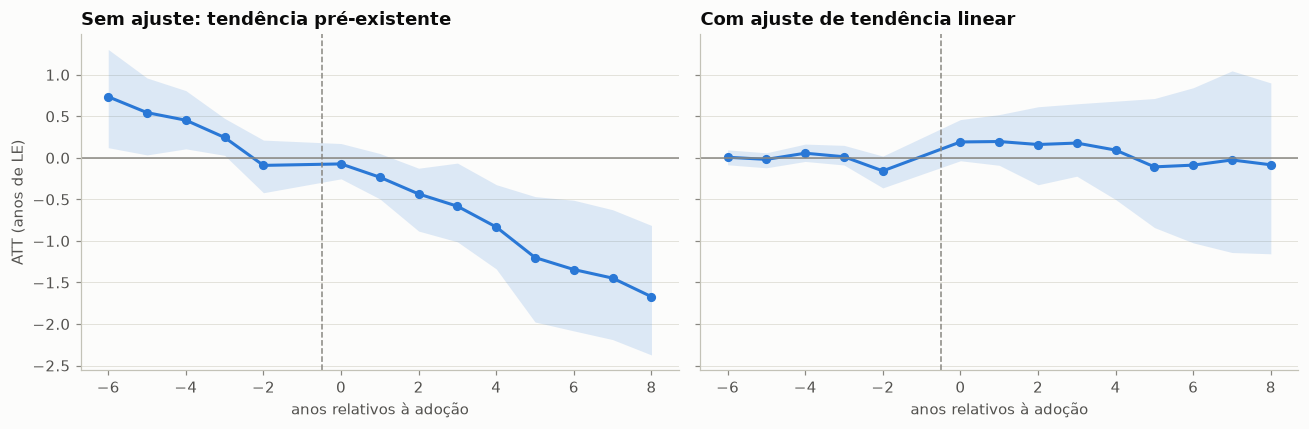

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, key, title in [(axes[0], "staggered", "Sem ajuste: tendência pré-existente"),
                       (axes[1], "staggered_detrended", "Com ajuste de tendência linear")]:
    ev = pd.DataFrame(cd[key]["event_study"])
    ax.fill_between(ev.e, [c[0] for c in ev.ci95], [c[1] for c in ev.ci95], color=style.HIGHLIGHT, alpha=0.15, lw=0)
    ax.plot(ev.e, ev.att, "o-", color=style.HIGHLIGHT)
    ax.axhline(0, color=style.INK["muted"], lw=1); ax.axvline(-0.5, color=style.INK["muted"], lw=1, ls="--")
    ax.set_title(title); ax.set_xlabel("anos relativos à adoção")
axes[0].set_ylabel("ATT (anos de LE)")
plt.tight_layout(); plt.show()

**Leitura:** o painel da esquerda é o diagnóstico-chave. Os coeficientes **pré-adoção já descem
em linha reta** — os tratados (renda média) crescem mais devagar que os nunca-tratados (os mais
pobres, em convergência acelerada) *antes* do tratamento. Não há quebra em e = 0: o "efeito
negativo" do TWFE é essa tendência. Removida a tendência (direita), o ATT fica em torno de zero.

Limites: o tratamento é o cruzamento de um índice que sobe continuamente (não um choque de
política discreto), e o grupo nunca-tratado é estruturalmente diferente. É evidência de
**ausência de efeito detectável**, não prova de efeito nulo.

## 3. Controle sintético (de-meaned) para países "herói"

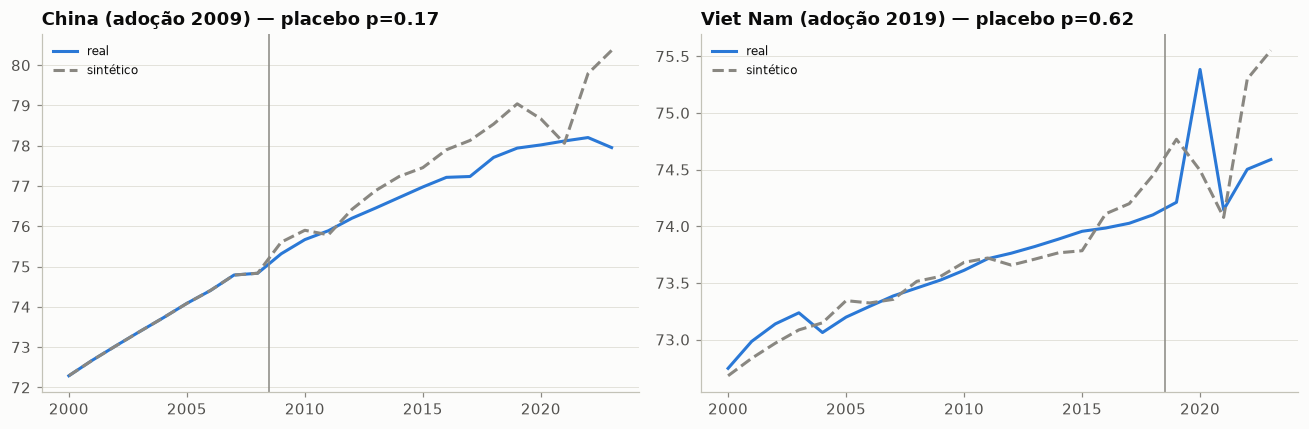

China | gap pós médio: -0.68 | RMSPE pré: 0.0 | principais doadores: {'MMR': 0.058, 'TCD': 0.047, 'PHL': 0.046, 'LSO': 0.044, 'ERI': 0.043}
Viet Nam | gap pós médio: -0.27 | RMSPE pré: 0.14 | principais doadores: {'VUT': 0.93, 'SYR': 0.056, 'SOM': 0.007, 'HTI': 0.004, 'CAF': 0.002}


In [6]:
fig, axes = plt.subplots(1, len(cd["synthetic_control"]), figsize=(12, 4))
for ax, sc in zip(np.atleast_1d(axes), cd["synthetic_control"]):
    s = sc["series"]
    ax.plot(s["years"], s["actual"], color=style.HIGHLIGHT, label="real")
    ax.plot(s["years"], s["synthetic"], color=style.INK["muted"], ls="--", label="sintético")
    ax.axvline(sc["treat_year"] - 0.5, color=style.INK["muted"], lw=1)
    ax.set_title(f"{sc['name']} (adoção {sc['treat_year']}) — placebo p={sc['placebo_p']:.2f}")
    ax.legend(fontsize=8)
plt.tight_layout(); plt.show()
for sc in cd["synthetic_control"]:
    print(sc["name"], "| gap pós médio:", round(sc["att_post_mean"], 2), "| RMSPE pré:", round(sc["rmspe_pre"], 2),
          "| principais doadores:", sc["top_donors"])

**Leitura:** para os dois países tratados mais populosos com pré e pós-período longos, o gap
pós-adoção é pequeno e **negativo** (China −0.7, Vietnã −0.3 ano) e não se distingue dos placebos
(p de permutação 0.18 e 0.62): **nenhum efeito positivo detectável**. Consistente com o DiD
ajustado. Ressalva: com 9 anos de pré-período e ~60 doadores, o ajuste da China é quase perfeito
(RMSPE pré ≈ 0) — sinal de sobreajuste, o que torna o gap pós menos informativo.

## Conclusão

A base não sustenta a narrativa "cruzar um limiar de cobertura UHC acelera a expectativa de vida"
— as diferenças que aparecem são explicadas por trajetórias pré-existentes de convergência.
O experimento simulado mostra por quê isso é difícil de medir: mesmo *com* randomização,
~190 países dão pouco poder para efeitos de ~1 ano.